<div style="border:solid green 5px; padding: 20px">



<font size="5"> Тестовое задание Data Science №2

<font size="5"><b>Цель проекта

<font size="2"><b>Создать прогностическую модель рисков беременных.


<font size="5"><b>Задачи проекта

<ul>
    <li><strong>Анализ данных:</strong>
        <ul>
            <li>Исследовать данные, обработать пропуски и выбросы.</li>
        </ul>
    </li>
    <li><strong>Предобработка данных:</strong>
        <ul>
            <li>Преобразовать категориальные переменные, нормализовать числовые данные, создать целевой признак <code>target</code>.</li>
        </ul>
    </li>
    <li><strong>Разделение данных:</strong>
        <ul>
            <li>Разделить данные на тренировочную и тестовую выборки.</li>
        </ul>
    </li>
    <li><strong>Обучение моделей:</strong>
        <ul>
            <li>Обучить и настроить модели машинного обучения для прогнозирования рисков беременных.</li>
        </ul>
    </li>
    <li><strong>Оценка и выбор модели:</strong>
        <ul>
            <li>Оценить модели по ключевым метрикам и выбрать лучшую.</li>
        </ul>
    </li>
    <li><strong>Анализ важности признаков:</strong>
        <ul>
            <li>Определить ключевые факторы, влияющие риск беременных.</li>
        </ul>
    </li>
</ul>

<font size="5"><strong>Исходные данные.</strong></p>

<p><strong>Описание данных</strong><br>Данные состоят из файла csv, содержащим следующие признаки:<br><strong>Age:</strong> — Age in years when a woman is pregnant;<br><strong>SystolicBP: </strong>— Upper value of Blood Pressure in mmHg, another significant attribute during pregnancy;<br><strong>DiastolicBP</strong> — Lower value of Blood Pressure in mmHg, another significant attribute during pregnancy;<br><strong>BS:</strong> — Blood glucose levels is in terms of a molar concentration, mmol/L;<br><strong>HeartRate:</strong> — A normal resting heart rate in beats per minute;<br><strong>Risk Level:</strong> — Predicted Risk Intensity Level during pregnancy considering the previous attribute;<br>&nbsp;</p>
<p><strong>

In [4]:
!pip install phik -q
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 9.2 MB/s eta 0:00:00


#### Импорты библиотек

In [69]:
# Основные библиотеки.
import pandas as pd
import warnings
import os
import re
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Для анализа и корреляции.
import phik
from phik.report import plot_correlation_matrix

# Подготовка данных и модели
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

# Для оценки модели
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    f1_score
)


# Игнорировать предупреждения
warnings.filterwarnings('ignore')

#### Константы и цветовые настройки

In [15]:
warnings.simplefilter(action='ignore', category=Warning)

sns.set_theme(style='whitegrid')
colors = sns.color_palette('deep')

RANDOM_STATE = 120424
TEST_SIZE = 0.25

#### Функции

In [16]:
def first_view(df):
    print('10 случайных строк:'); display(df.sample(10))
    print('-' * 100)
    print('Информация о датафрейме:\n', df.info(), sep='')
    print("-" * 100)
    print('Количество пропусков:\n', df.isna().sum(), sep='')
    print('-' * 100)
    print(f'- Количество явных дубликатов: {df.duplicated().sum()}')
    print(f'- Количество строк и столбцов: {df.shape}')
    print(f'- Название столбцов: {df.columns}')

In [17]:
def camel_to_snake(name):
    s1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    s2 = re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1)
    return s2.lower()

In [18]:
def plot_h_bp(dataframe, numeric_columns, bins):

    fig, axes = plt.subplots(nrows=len(numeric_columns),
                             ncols=2,
                             figsize=(16, 5*len(numeric_columns))
                            )

    for idx, column in enumerate(numeric_columns):
        sns.histplot(dataframe[column],
                     bins=bins,
                     ax=axes[idx, 0],
                     kde=True
                    )
        axes[idx, 0].set_title(f'Гистограмма распределения для {column}',
                               fontweight='bold',
                               fontsize=14
                              )
        axes[idx, 0].set_ylabel('Частота')
        axes[idx, 0].axvline(dataframe[column].mean(),
                             color='red',linestyle = ':',
                             label='Среднее'
                            )
        axes[idx, 0].axvline(dataframe[column].median(),
                             color='purple',
                             linestyle = '--',
                             label='Медиана'
                            )
        axes[idx, 0].legend()
        sns.boxplot(x=dataframe[column],
                    ax=axes[idx, 1],
                    flierprops=dict(marker='o',
                                    markerfacecolor='red',
                                    markersize=8)
                   )
        axes[idx, 1].set_title(f'Боксплот для {column}',
                               fontweight='bold',
                               fontsize=14
                              )
    plt.tight_layout()
    plt.show()


In [19]:
def describe_numeric_column(df, column_name):
    for column in column_name:
        median_value = round(df[column].median(), 2)
        mean_value = round(df[column].mean(), 2)
        min_value = round(df[column].min(), 2)
        max_value = round(df[column].max(), 2)

        print(f'\033[1m{column}:\033[0m медиана/среднее= \
{median_value}/{mean_value}, min = {min_value}, max = {max_value}')

In [21]:
def plot_hist_boxplot_target(df, numeric_column, target):
    fig, axs = plt.subplots(ncols=2, figsize=(12, 6))
    sns.histplot(data=df,
                 x=numeric_column,
                 hue=target,
                 multiple='stack',
                 bins=20,
                 kde=True,
                 ax=axs[0]
                 )
    axs[0].set_title('Распределение признаков')
    sns.boxplot(data=df, y=target, x=numeric_column, ax=axs[1])
    axs[1].set_title('Боксплот признаков')
    plt.tight_layout()
    plt.show()


In [22]:
def phik_matrix_heatmap(df, numeric_columns):
    '''Считает фи корреляцию и строит хитмап'''
    phik_matrix = phik.phik_matrix(
        df,
        interval_cols=numeric_columns
    )

    plot_correlation_matrix(phik_matrix.values,
                        x_labels=phik_matrix.columns,
                        y_labels=phik_matrix.index,
                        vmin=0, vmax=1, color_map='Reds',
                        title='Тепловая карта матрицы Phik',
                        fontsize_factor=0.9,
                        figsize=(6, 5)
                       )

In [23]:
def target_phik_heatmap(df, target_column):
    '''Строим хитмап матрицы Phik для целевого признака,
    с  сортировкой по убыванию
    '''
    phik_matrix_target = phik.phik_matrix(df,
                                   interval_cols=df.select_dtypes(include='number').
                                   columns.tolist())[target_column].sort_values(ascending=False)
    plt.figure(figsize=(1, 6))
    sns.heatmap(phik_matrix_target.to_frame(),
                annot=True,
                cmap='coolwarm',
                fmt='.4f',
                annot_kws={'fontsize':8}
               )
    plt.title(f'Тепловая карта матрицы Phik для целевого признака "{target_column}"')
    plt.show()

### Загрузка данных

In [24]:
local_path = '/Users/alexeyfilichkin/Desktop/TEST/heals_risk/Maternal Health Risk Data Set.csv'
colab_path = '/content/Maternal Health Risk Data Set.csv'

In [25]:
try:
  df = pd.read_csv(local_path)
except:
  df = pd.read_csv(colab_path)

In [26]:
first_view(df)

10 случайных строк:


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
449,48,120,80,11.0,98.0,88,high risk
190,23,120,90,6.1,98.0,60,low risk
62,12,95,60,7.2,98.0,77,low risk
696,23,90,60,6.7,98.0,76,low risk
815,15,120,80,7.5,98.0,70,mid risk
607,45,120,95,7.5,98.0,66,low risk
850,12,100,50,6.4,98.0,70,mid risk
127,55,140,95,19.0,98.0,77,high risk
232,55,140,80,7.2,101.0,76,high risk
207,15,120,80,7.0,98.0,70,low risk


----------------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB
Информация о датафрейме:
None
----------------------------------------------------------------------------------------------------
Количество пропусков:
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64
-------------------------------------------------------------------

 Приведем к змеиному регистру название признаков

In [27]:
df.columns = [camel_to_snake(col) for col in df.columns]

In [28]:
df.head(5)

,age,systolic_bp,diastolic_bp,bs,body_temp,heart_rate,risk_level
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


Удалим дубликаты

In [29]:
df = df.drop_duplicates().reset_index(drop=True)

In [30]:
df.shape

(452, 7)

#### Вывод по загрузке данных

- загружен DataFrame от заказчика
- обнаруженно 562 явных дубликата
- пропуски отсутствуют

### Исследовательский анализ данных

#### Баланс классов

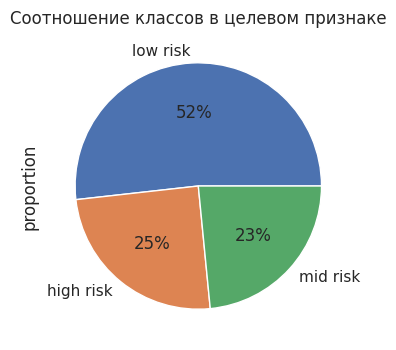

In [31]:
balance = df['risk_level'].value_counts(normalize=True)

balance.plot(kind='pie',
             autopct='%0.0f%%',
             figsize=(4, 4),
             labels=['low risk', 'high risk', 'mid risk']
            )
plt.title('Соотношение классов в целевом признаке');

Класс low_risk имеет преобладание над другими, в дальнейшем целесообразно воспользоваться семплированием

In [32]:
numeric_columns = df.select_dtypes(include=['int', 'float']).columns

In [33]:
numeric_columns

Index(['age', 'systolic_bp', 'diastolic_bp', 'bs', 'body_temp', 'heart_rate'], dtype='object')

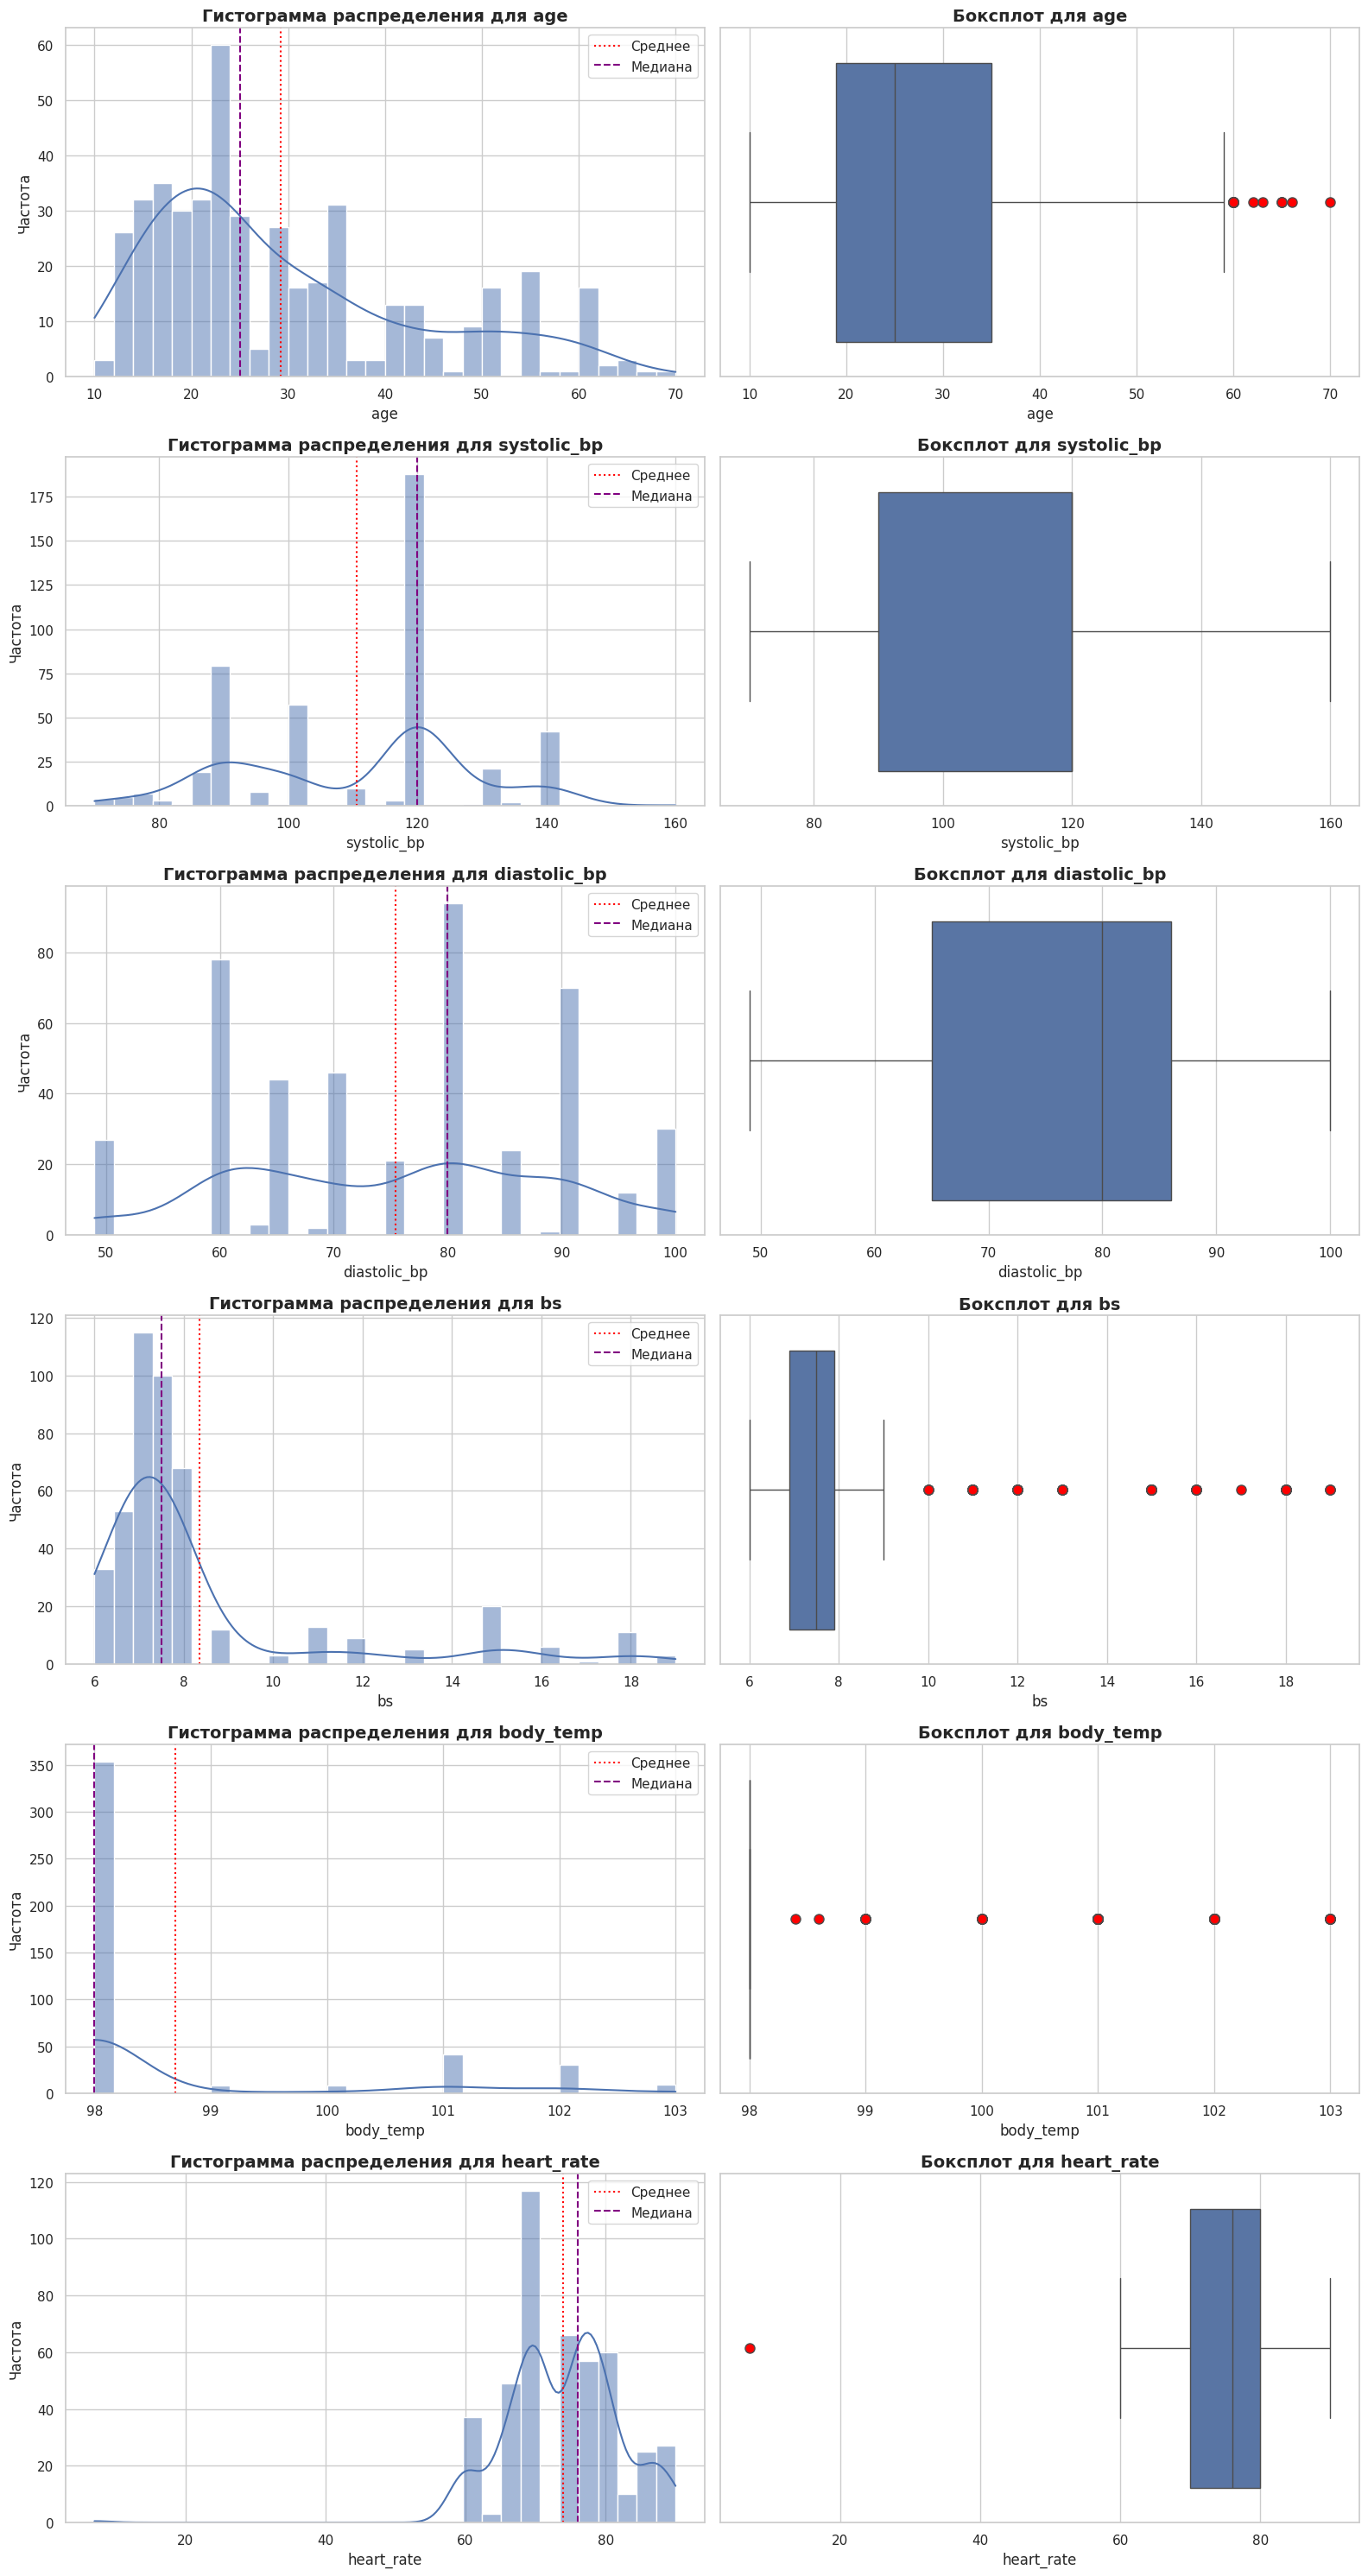

In [34]:
plot_h_bp(df, numeric_columns, 30)

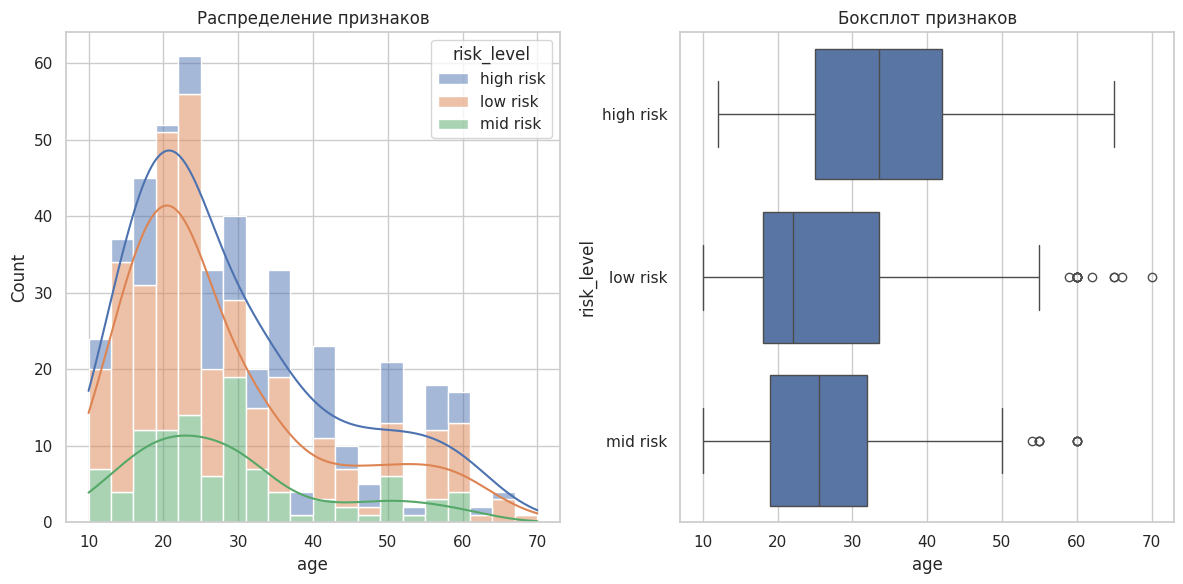

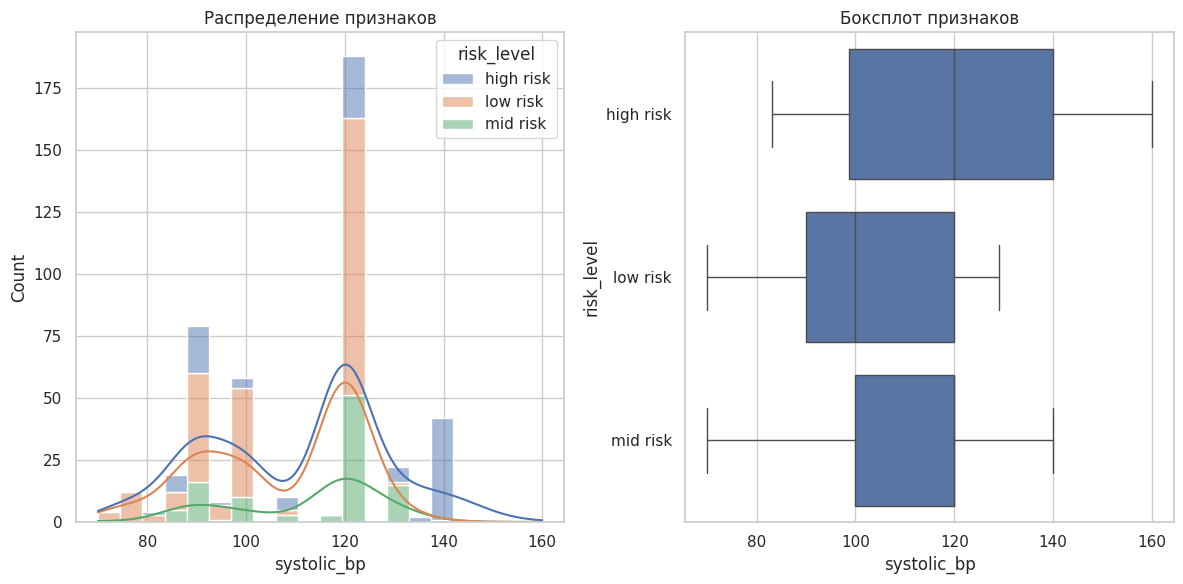

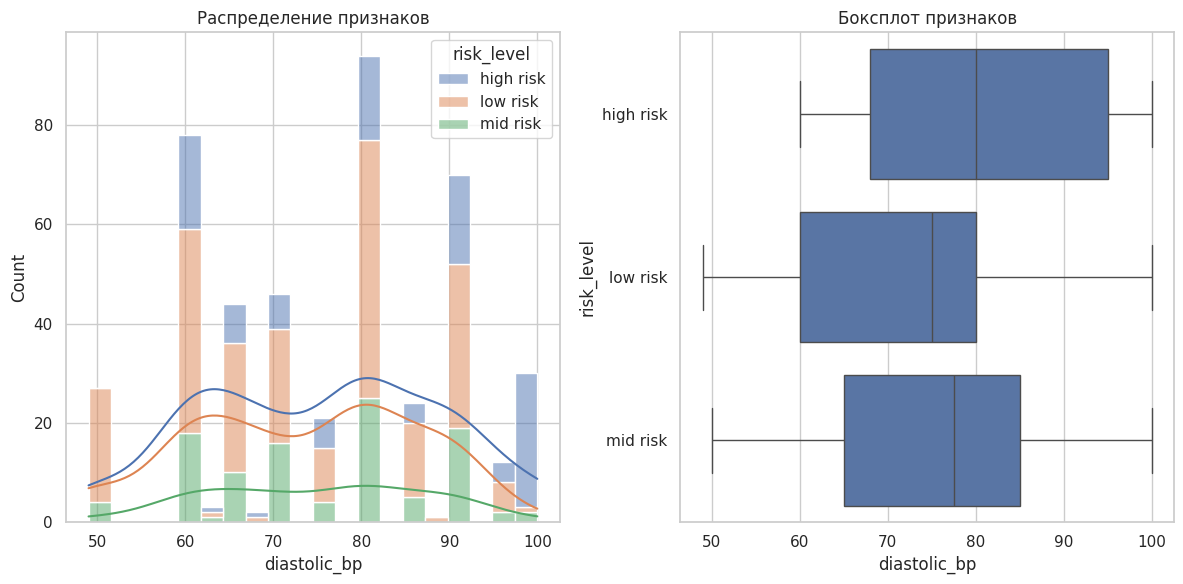

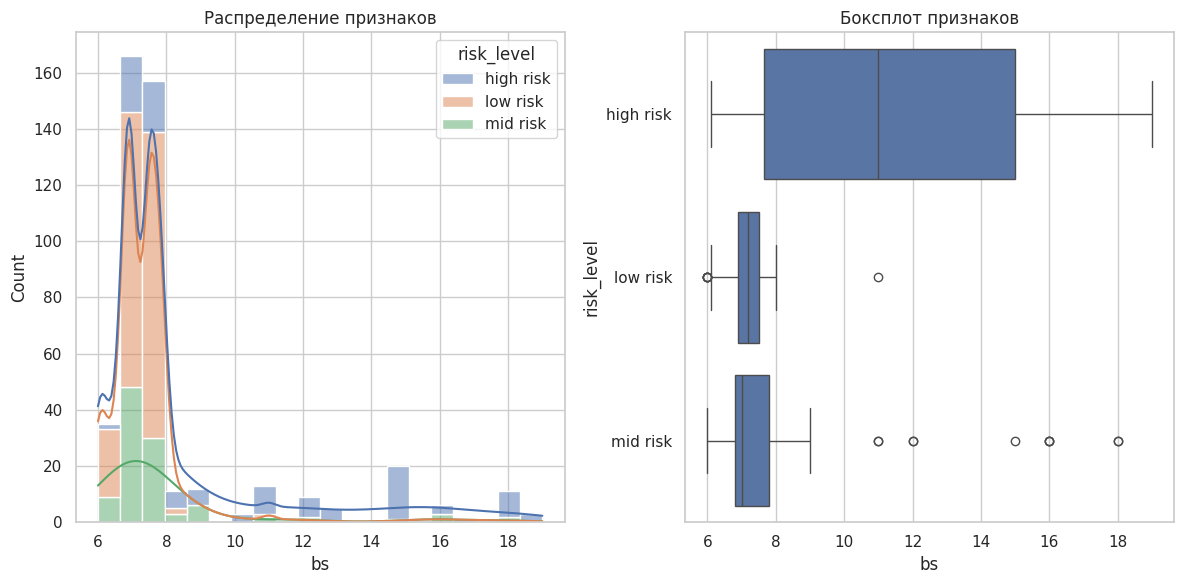

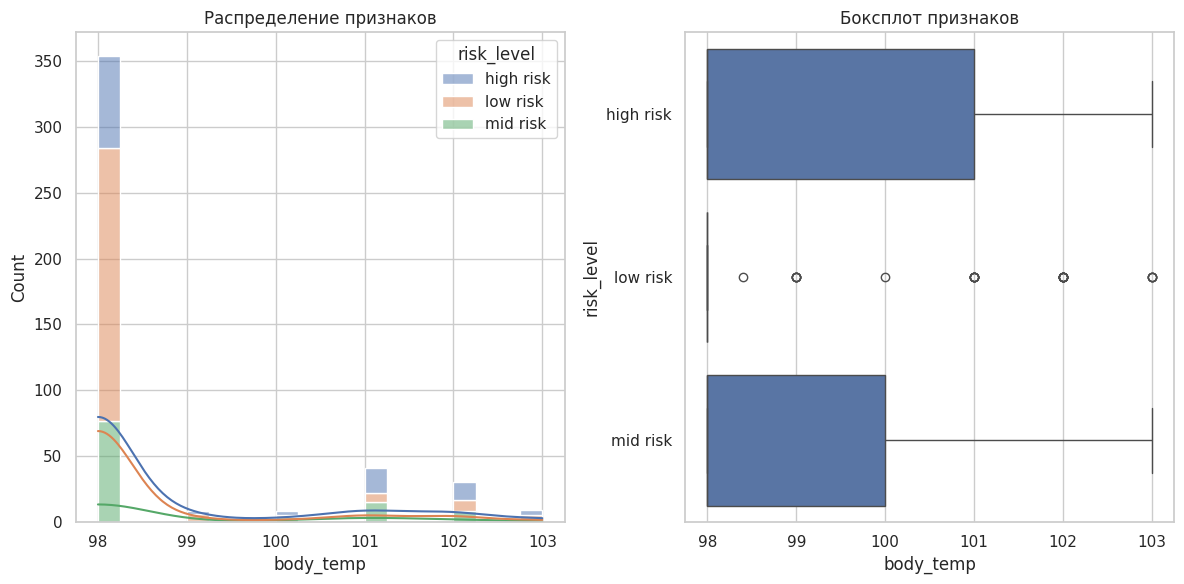

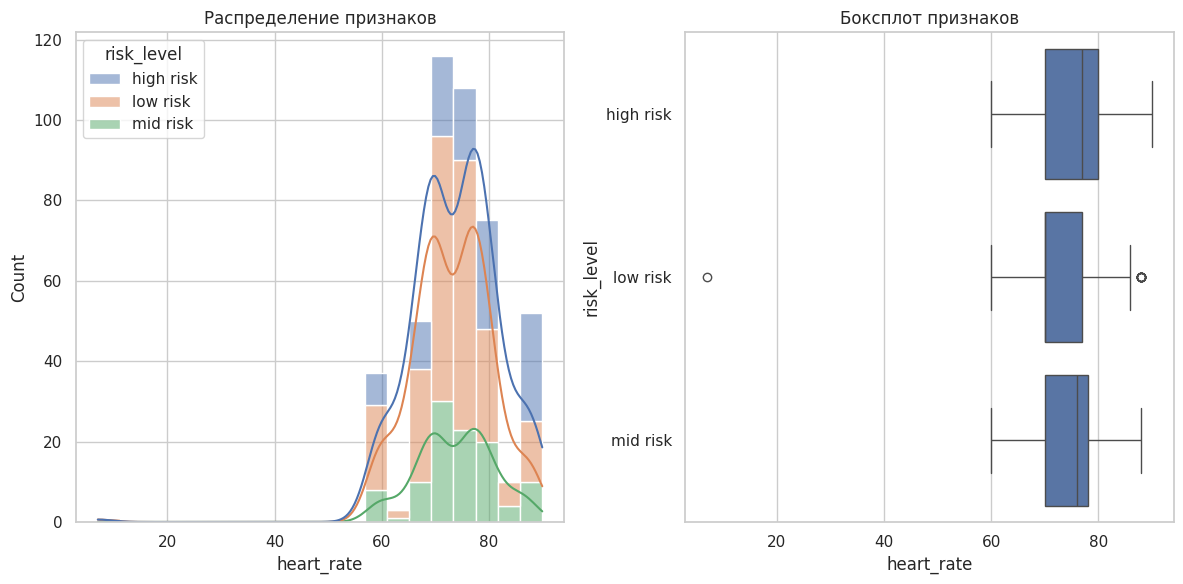

In [35]:
for num in numeric_columns:
    plot_hist_boxplot_target(df, num, 'risk_level')

In [36]:
describe_numeric_column(df, numeric_columns)

age: медиана/среднее= 25.0/29.19, min = 10, max = 70
systolic_bp: медиана/среднее= 120.0/110.55, min = 70, max = 160
diastolic_bp: медиана/среднее= 80.0/75.42, min = 49, max = 100
bs: медиана/среднее= 7.5/8.35, min = 6.0, max = 19.0
body_temp: медиана/среднее= 98.0/98.69, min = 98.0, max = 103.0
heart_rate: медиана/среднее= 76.0/73.95, min = 7, max = 90


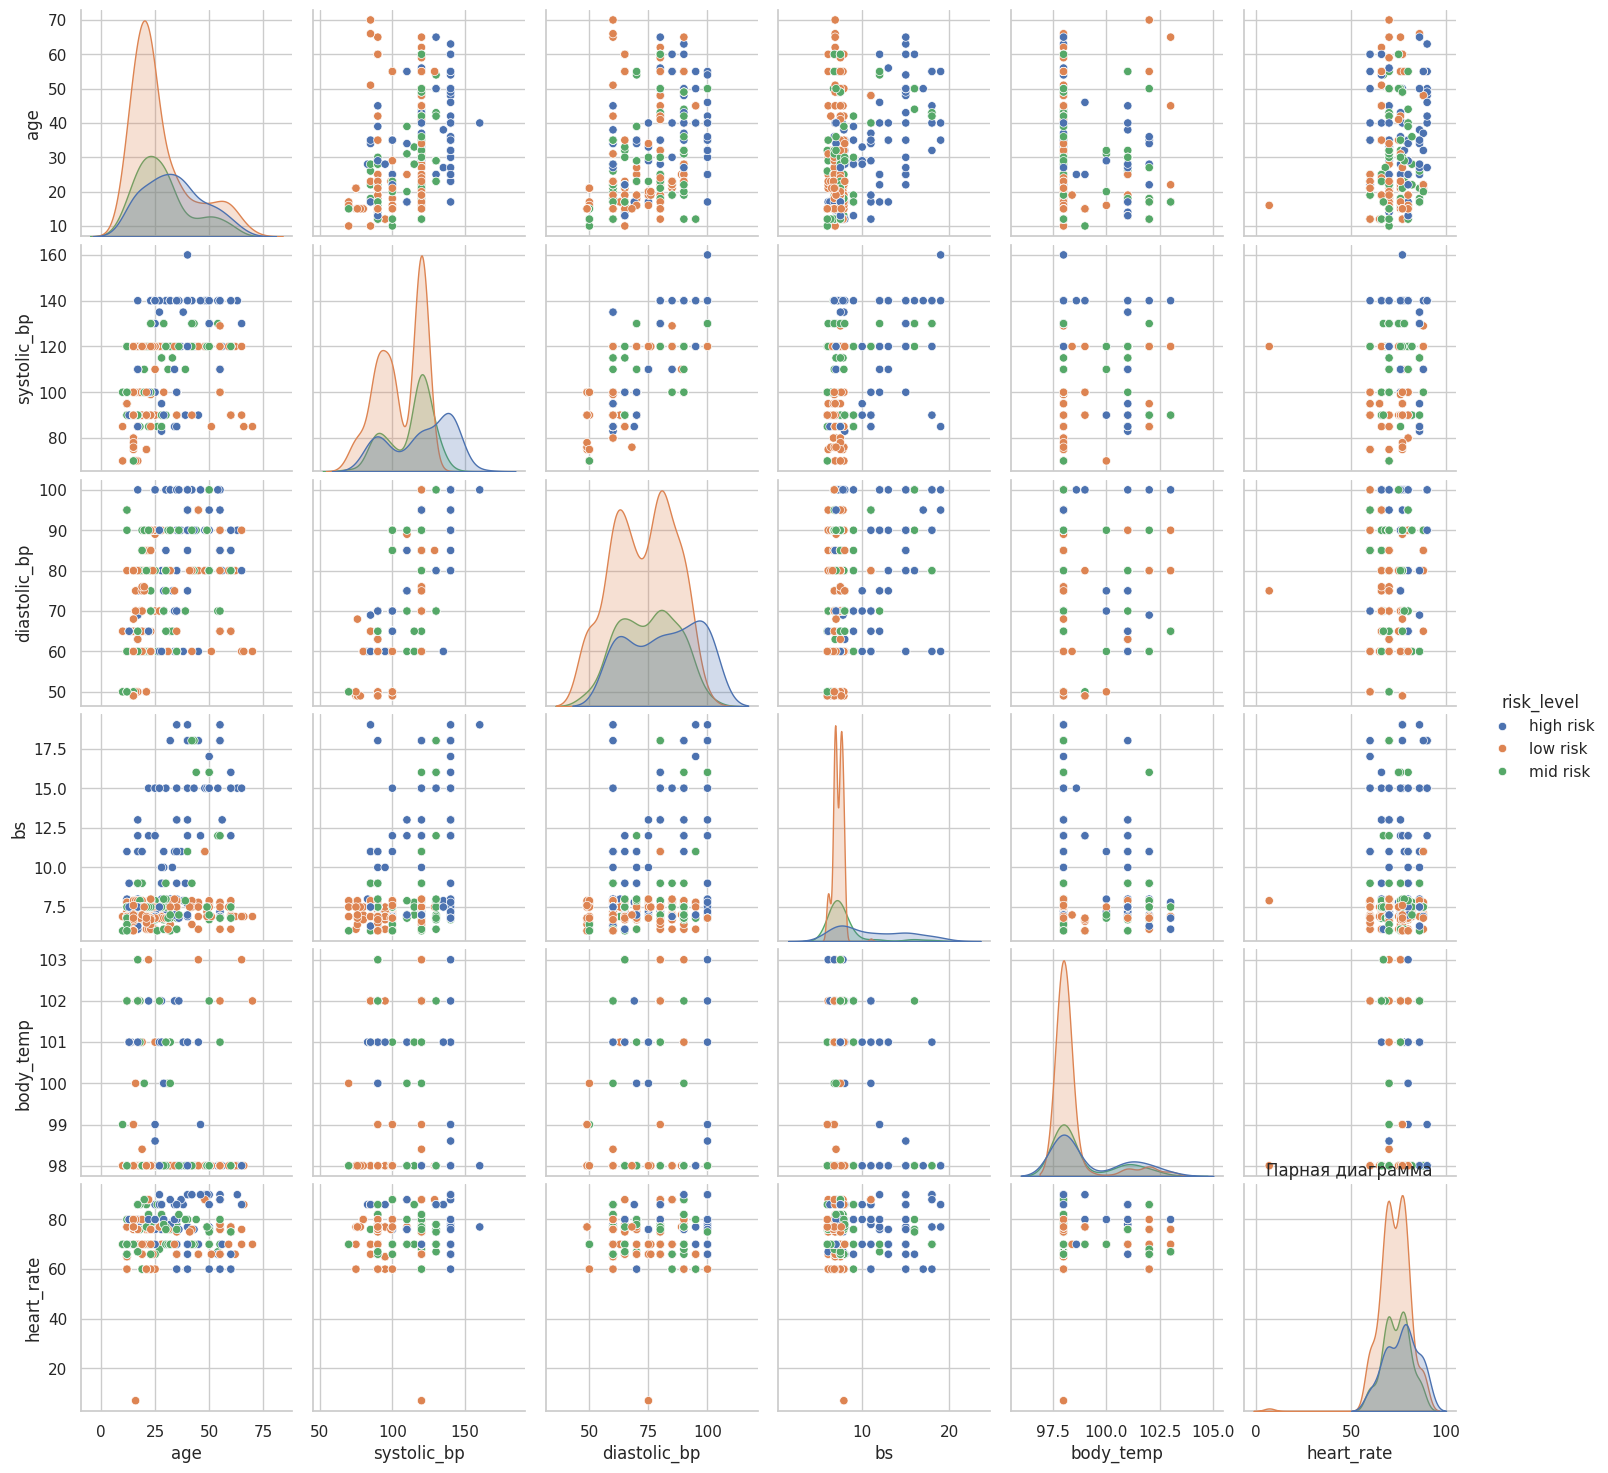

In [37]:
sns.pairplot(data=df, hue='risk_level', vars=numeric_columns)
plt.title('Парная диаграмма')
plt.show()

####  Обработка аномальных значений

1. Уделение данных с heart_rate меньше 40
2. Разделим на категории данные body_temp до 98 и более

In [38]:
def categorize_body_temp(temp):
    try:
        if 0 <= temp <= 98:
            return 1
        else:
            return 0
    except:
        pass

In [39]:
df['body_temp'] = df['body_temp'].apply(categorize_body_temp)
df = df.query('heart_rate > 40')

In [40]:
df.head(5)

,age,systolic_bp,diastolic_bp,bs,body_temp,heart_rate,risk_level
0,25,130,80,15.0,1,86,high risk
1,35,140,90,13.0,1,70,high risk
2,29,90,70,8.0,0,80,high risk
3,30,140,85,7.0,1,70,high risk
4,35,120,60,6.1,1,76,low risk


### Корреляционный анализ

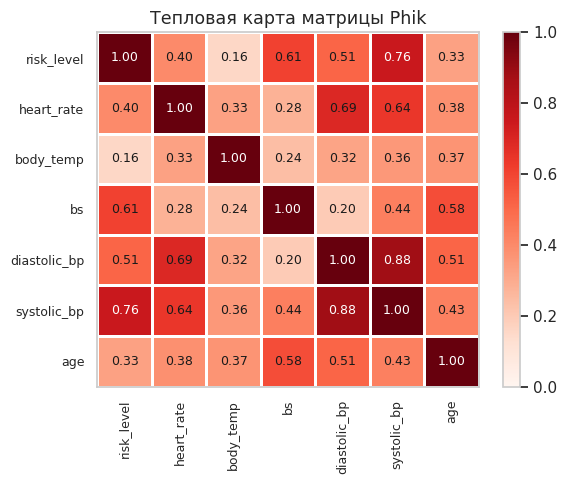

In [41]:
phik_matrix_heatmap(df, numeric_columns)

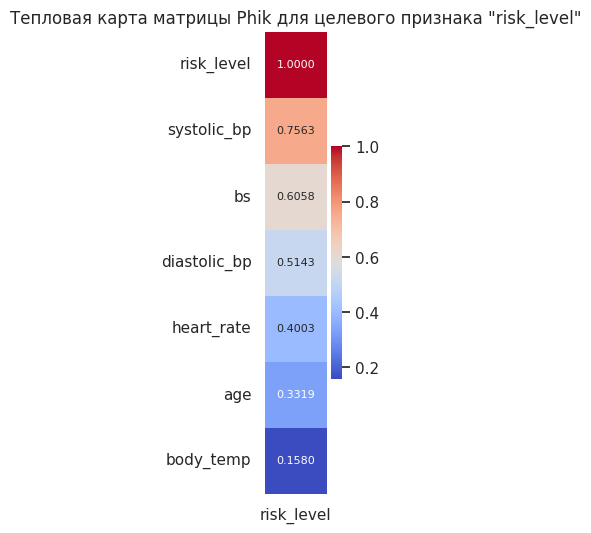

In [42]:
target_phik_heatmap(df, 'risk_level')

#### Вывод по кореляционному анализу

In [43]:
df.columns

Index(['age', 'systolic_bp', 'diastolic_bp', 'bs', 'body_temp', 'heart_rate',
       'risk_level'],
      dtype='object')

Самая высокая корреляция с  Целевым признаком (risk_level):
- systolic_bp(0.76),
- bs(0.61),
- rdiastolic_bp(0.51)

### Подготовка данных для обучения моделей

#### Разбивка на обучающие и тестовые выборки

In [44]:
X = df.drop(['risk_level'], axis=1)
y = df['risk_level']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y)

#### Кодироание целевого признака

In [48]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

In [49]:
print(label_encoder.classes_)

['high risk' 'low risk' 'mid risk']


#### Решения проблемы дисбаланса классов

In [50]:
sampler = SMOTE(random_state=RANDOM_STATE,
                k_neighbors=20
               )

In [51]:
X_train_sampled, y_train_sampled = sampler.fit_resample(X_train, y_train)

In [52]:
X_train_sampled.shape, X_train.shape

((525, 6), (338, 6))

### Обучение моделей

В качестве основной метрики на кросс-валидации выберем ROC-AUC с методом ovo — «один против одного». Подходит к ситуациям, когда примеров одного класса больше, чем другого.

#### Модель DecisionTreeClassifier

In [53]:
model_dt = DecisionTreeClassifier(random_state=RANDOM_STATE)

parameters_dt = {
    'min_samples_split': range(2, 11),
    'min_samples_leaf': range(1, 11),
    'max_depth': range(2, 11),
}

rs_dt = RandomizedSearchCV(
    model_dt,
    parameters_dt,
    n_jobs=-1,
    scoring='roc_auc_ovo',
    random_state=RANDOM_STATE
)

rs_dt.fit(X_train_sampled, y_train_sampled)

print(f'Лучшая метрика ROC-AUC на кросс-валидации: {rs_dt.best_score_}')
print(f'Параметры лучшей модели: {rs_dt.best_params_}')

Лучшая метрика ROC-AUC на кросс-валидации: 0.8399047619047619
Параметры лучшей модели: {'min_samples_split': 6, 'min_samples_leaf': 6, 'max_depth': 7}


In [54]:
best_model_rs = rs_dt.best_estimator_
y_pred_rs = best_model_rs.predict(X_test)
probas_rs = best_model_rs.predict_proba(X_test)

In [56]:
roc_rs = roc_auc_score(y_test, probas_rs, multi_class='ovo')
print('Метрика ROC-AUC лучшей модели на тестовой выборке:', round(roc_rs,2))

Метрика ROC-AUC лучшей модели на тестовой выборке: 0.73


In [57]:
f1_rs = f1_score(y_test, y_pred_rs, average='macro')
print('Метрика F1 лучшей модели на тестовой выборке:', round(f1_rs,2))

Метрика F1 лучшей модели на тестовой выборке: 0.58


#### Модель CatBoostClassifier

In [58]:
model_cb = CatBoostClassifier(
    verbose=False,
    loss_function='MultiClass'
)

In [59]:
param_cb = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.5],
    'depth': [3, 6, 9]
}

In [60]:
rs_cb = RandomizedSearchCV(
    model_cb,
    param_cb,
    n_jobs=-1,
    scoring='roc_auc_ovo',
    random_state=RANDOM_STATE
)
rs_cb.fit(X_train_sampled, y_train_sampled)

RandomizedSearchCV(estimator=<catboost.core.CatBoostClassifier object at 0x7c6ecab029e0>,
                   n_jobs=-1,
                   param_distributions={'depth': [3, 6, 9],
                                        'iterations': [100, 200, 300],
                                        'learning_rate': [0.01, 0.1, 0.5]},
                   random_state=120424, scoring='roc_auc_ovo')

In [61]:
print(f'Лучшая метрика ROC-AUC на кросс-валидации: {rs_cb.best_score_}')
print(f'Параметры лучшей модели: {rs_cb.best_params_}')

Лучшая метрика ROC-AUC на кросс-валидации: 0.8958639455782313
Параметры лучшей модели: {'learning_rate': 0.1, 'iterations': 200, 'depth': 6}


In [62]:
best_model_cb = rs_cb.best_estimator_
y_pred_cb = best_model_cb.predict(X_test)
probas_cb = best_model_cb.predict_proba(X_test)

In [64]:
roc_cb = roc_auc_score(y_test, probas_cb, multi_class='ovo')
print('Метрика ROC-AUC лучшей модели на тестовой выборке:', round(roc_cb,2))

Метрика ROC-AUC лучшей модели на тестовой выборке: 0.79


In [65]:
f1_cb = f1_score(y_test, y_pred_cb, average='macro')
print('Метрика F1 лучшей модели на тестовой выборке:', round(f1_cb,2))

Метрика F1 лучшей модели на тестовой выборке: 0.62


In [66]:
results = pd.DataFrame({'roc-auc (cv)': [rs_dt.best_score_, rs_cb.best_score_],
                       'roc-auc (test)': [roc_rs, roc_cb],
                       'F1 (test)': [f1_rs, f1_cb]},
                       ['DecisionTreeClassifier', 'CatBoostClassifier'])

### Метрики и матрицы ошибок

In [67]:
results.sort_values(by='roc-auc (test)', ascending=False)

,roc-auc (cv),roc-auc (test),F1 (test)
CatBoostClassifier,0.895864,0.793126,0.622243
DecisionTreeClassifier,0.839905,0.729093,0.584935


Модели классификации показывают следующие результаты:

CatBoostClassifier:

- ROC-AUC: 0.79
- F1: 0.62

DecisionTreeClassifier:

- ROC-AUC: 0.73
- F1: 0.58


**Вывод:**

CatBoostClassifier демонстрирует лучшее значение ROC-AUC и точности по сравнению с DecisionTreeClassifier. Это означает, что CatBoostClassifier более эффективен в различении классов и имеет более высокую общую точность.



F1 также выше у CatBoostClassifier, что говорит производительности модели выше среднего

Таким образом, если цель — максимизировать как точность, так и способность различать классы, CatBoostClassifier выглядит как более предпочтительный выбор.

#### CatBoostClassifier

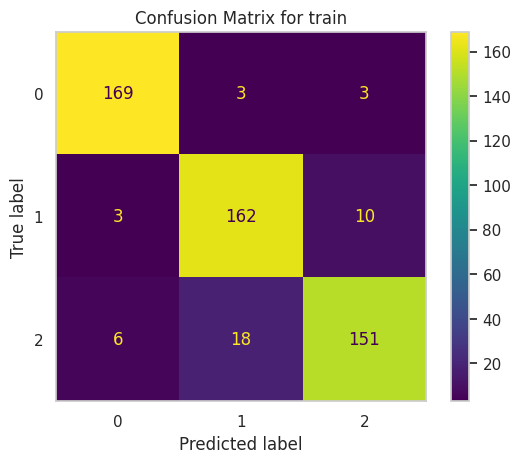

In [70]:
disp_train = ConfusionMatrixDisplay.from_estimator(best_model_cb,
                                                   X_train_sampled,
                                                   y_train_sampled
                                                  )

disp_train.ax_.grid(False)
disp_train.ax_.set_title('Confusion Matrix for train');

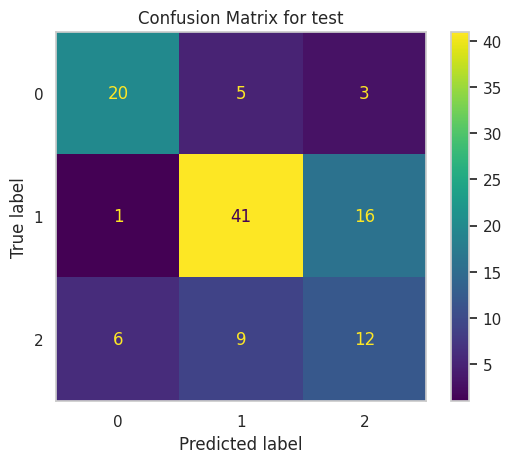

In [71]:
disp_test = ConfusionMatrixDisplay.from_estimator(best_model_cb,
                                                   X_test,
                                                   y_test
                                                 )
disp_test.ax_.grid(False)
disp_test.ax_.set_title('Confusion Matrix for test');


В данном случае модель CatBoostClassifier на тестовых даных ошибочно указывает низкий риск у 5 пациентов с потенциально высоким риском и у 9 пациентов со средним риском, что дает возможность использовать данную модель только в предварительном анализе, так как с медицинской точки здения ложно-орицательные прогнозы недопустимы.

Целесообразно собрать больше данных и обучить модель на большем датасете.


#### Важность признаков

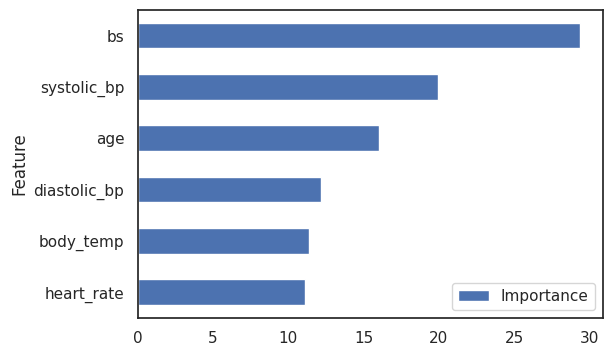

In [72]:
coefficients = best_model_cb.feature_importances_

sns.set_style('white')
feature_importance = pd.DataFrame({'Feature': X_train_sampled.columns, 'Importance': np.abs(coefficients)})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
feature_importance.plot(x='Feature', y='Importance', kind='barh', figsize=(6, 4));

### Общий вывод

- заказчиком предоставдлен датасет с данными о 1014 пациентах, где обнаруженно и удалено 562 явных дубликата, пропуски данных отсутствовали;

- Самая высокая корреляция с целевым признаком (risk_level): systolic_bp(0.76), bs(0.61), rdiastolic_bp(0.51);

- Произведено обучение двух моделей: DecisionTreeClassifier и CatBoostClassifier

- CatBoostClassifier демонстрирует лучшее значение ROC-AUC и точности по сравнению с DecisionTreeClassifier. Это означает, что CatBoostClassifier более эффективен в различении классов и имеет более высокую общую точность. Таким образом, если цель — максимизировать как точность, так и способность различать классы, CatBoostClassifier выглядит как более предпочтительный выбор;

- важнами признаками влияющими на уровень риска, являются: BS: — Blood glucose levels is in terms of a molar concentration, mmol/L, SystolicBP: — Upper value of Blood Pressure in mmHg, another significant attribute during pregnancy, Age: — Age in years when a woman is pregnant.


### Рекомендации заказчику

- обученную модель целесообразно использовать только в предварительном анализе, так как с медицинской точки здения ложно-орицательные прогнозы недопустимы;

- целесообразно собрать больше данных и обучить модель на большем датасете.